# GreenLedger — Low-Cost Proxy Sustainability Risk Scoring for Small Businesses

**Research question.** How accurately can interpretable machine learning predict a small
commercial building's energy-intensity risk tier using only the operational details a
business owner could report from memory in a phone call — compared to models given the
fuller, inspection-grade building detail an energy auditor would collect? Does an ANN
outperform classical ML at this data scale?

**Data.** U.S. EIA [2018 Commercial Buildings Energy Consumption Survey (CBECS)](https://www.eia.gov/consumption/commercial/data/2018/),
the public-use microdata file: 6,436 real, individually surveyed U.S. commercial buildings
(disclosure-masked, no names/addresses). This notebook filters to buildings whose principal
activity looks like an independent small business — food sales, food service, strip
shopping center, retail (non-mall), and service — under 25,000 sq ft, giving **741 real
buildings**.

**Design.** Every building has *both* cheap self-reportable fields (square footage,
headcount, hours open, rough building age) *and* inspection-grade fields (wall/roof
material, glass %, ceiling height, basement, elevator) recorded in the same survey. That
lets us run a **paired ablation**: train each model twice on the identical buildings —
once on proxy-only features, once on proxy+audit features — and read the accuracy gap
directly, rather than comparing two different samples.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
pd.set_option("display.width", 120)


## 1. Load and filter to the small-business subset

In [2]:
COLS = ["PBA","REGION","SQFT","NFLOOR","YRCONC","WKHRS","NWKER","HT1","COOL",
        "WLCNS","RFCNS","GLSSPC","FLCEILHT","ATTIC","BASEMNT","ELEVTR","MONUSE","MFBTU"]

raw = pd.read_csv("../data/cbecs2018_final_public.csv", usecols=COLS)

SMALL_BIZ_PBA = {6: "Food sales", 15: "Food service", 23: "Strip shopping center",
                  25: "Retail other than mall", 26: "Service"}

df = raw[raw["PBA"].isin(SMALL_BIZ_PBA) & (raw["SQFT"] <= 25000) & raw["MFBTU"].notna()].copy()
df["business_type"] = df["PBA"].map(SMALL_BIZ_PBA)

print(f"Buildings after filtering: {len(df)} (of {len(raw)} total CBECS 2018 buildings)")
df["business_type"].value_counts()


Buildings after filtering: 741 (of 6436 total CBECS 2018 buildings)


business_type
Service                   282
Food service              212
Retail other than mall    129
Food sales                 65
Strip shopping center      53
Name: count, dtype: int64

## 2. Target: energy-intensity risk tier

`EUI = MFBTU / SQFT` — annual site energy per square foot, the standard building-energy benchmarking metric. Split into tertiles so the target is a 3-class risk label (Low / Medium / High), matching how a business owner would actually want the result presented, rather than a raw regression number.

Tertile cutoffs (kBtu/sqft/yr): Low <= 47.1 < Medium <= 140.7 < High
risk_tier
Medium    247
Low       247
High      247
Name: count, dtype: int64


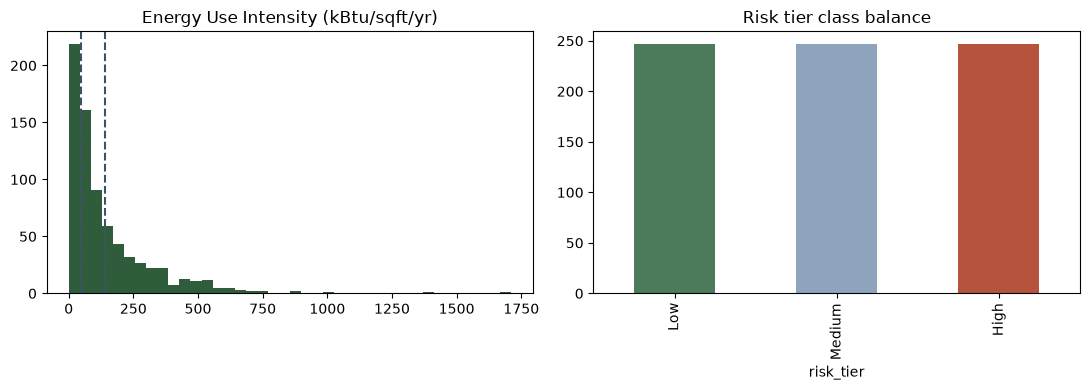

In [3]:
df["EUI"] = df["MFBTU"] / df["SQFT"]

q1, q2 = df["EUI"].quantile([1/3, 2/3])
def risk_tier(eui):
    if eui <= q1: return "Low"
    if eui <= q2: return "Medium"
    return "High"
df["risk_tier"] = df["EUI"].apply(risk_tier)

print(f"Tertile cutoffs (kBtu/sqft/yr): Low <= {q1:.1f} < Medium <= {q2:.1f} < High")
print(df["risk_tier"].value_counts())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df["EUI"], bins=40, color="#2f5d3c")
ax[0].axvline(q1, color="#3e5266", ls="--"); ax[0].axvline(q2, color="#3e5266", ls="--")
ax[0].set_title("Energy Use Intensity (kBtu/sqft/yr)")
df["risk_tier"].value_counts().reindex(["Low","Medium","High"]).plot(
    kind="bar", ax=ax[1], color=["#4c7a5a","#8ea4bd","#b5533c"])
ax[1].set_title("Risk tier class balance")
plt.tight_layout(); plt.show()


## 3. Two feature sets: proxy (cheap) vs proxy+audit (full)

**Proxy set** — anything an owner could state from memory in a 10-minute call: business type, region, square footage, floors, rough building-age bracket, weekly hours, headcount, and whether the building has heating/cooling at all.

**Audit-only additions** — things that need someone to actually look at the building: wall/roof construction material, % glass exterior, ceiling height, attic, basement floors, elevator.

In [4]:
def yesno(s):
    return (s == 1).astype(int)

df["ht1_bin"]   = yesno(df["HT1"])
df["cool_bin"]  = yesno(df["COOL"])
df["attic_bin"] = yesno(df["ATTIC"])
df["elevtr_bin"]= yesno(df["ELEVTR"].fillna(2))
df["basemnt_n"] = df["BASEMNT"].fillna(0)
df["flceilht_c"] = df["FLCEILHT"].clip(upper=55)
df["log_sqft"] = np.log(df["SQFT"])

proxy_num = ["log_sqft","NFLOOR","YRCONC","WKHRS","NWKER","MONUSE","ht1_bin","cool_bin"]
proxy_cat = ["business_type","REGION"]

audit_num = ["flceilht_c","attic_bin","basemnt_n","elevtr_bin","GLSSPC"]
audit_cat = ["WLCNS","RFCNS"]

def build_features(num_cols, cat_cols):
    X_num = df[num_cols].astype(float)
    X_cat = pd.get_dummies(df[cat_cols].astype(str), drop_first=True)
    return pd.concat([X_num, X_cat], axis=1)

X_proxy = build_features(proxy_num, proxy_cat)
X_audit = build_features(proxy_num + audit_num, proxy_cat + audit_cat)

LABELS = ["Low", "Medium", "High"]
y = pd.Categorical(df["risk_tier"], categories=LABELS, ordered=True).codes  # 0/1/2 - xgboost needs numeric targets

print("Proxy-only feature matrix:", X_proxy.shape)
print("Proxy+audit feature matrix:", X_audit.shape)


Proxy-only feature matrix: (741, 15)
Proxy+audit feature matrix: (741, 34)


## 4. Models

Logistic Regression (interpretable baseline) · Random Forest · XGBoost · a small MLP (the ANN comparison). Same train/test split and same random seed for every run so the proxy-vs-audit and model-vs-model comparisons are apples-to-apples.

In [5]:
def make_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=2000),
        "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=8, random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                  eval_metric="mlogloss", random_state=RANDOM_STATE),
        "ANN (MLP)": MLPClassifier(hidden_layer_sizes=(32,16), max_iter=2000,
                                    early_stopping=True, random_state=RANDOM_STATE),
    }

def evaluate(X, y, label):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
    scaler = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

    rows = []
    fitted = {}
    for name, model in make_models().items():
        needs_scaling = name in ("Logistic Regression", "ANN (MLP)")
        xtr_use, xte_use = (Xtr_s, Xte_s) if needs_scaling else (Xtr.values, Xte.values)
        model.fit(xtr_use, ytr)
        pred = model.predict(xte_use)
        cv = cross_val_score(model, scaler.transform(X) if needs_scaling else X.values, y,
                              cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                              scoring="accuracy")
        rows.append({
            "feature_set": label, "model": name,
            "test_accuracy": accuracy_score(yte, pred),
            "test_macro_f1": f1_score(yte, pred, average="macro"),
            "cv_accuracy_mean": cv.mean(), "cv_accuracy_std": cv.std(),
        })
        fitted[name] = (model, scaler if needs_scaling else None, Xte, yte, pred)
    return pd.DataFrame(rows), fitted

results_proxy, fitted_proxy = evaluate(X_proxy, y, "proxy-only")
results_audit, fitted_audit = evaluate(X_audit, y, "proxy+audit")
results = pd.concat([results_proxy, results_audit], ignore_index=True)
results.round(3)


,feature_set,model,test_accuracy,test_macro_f1,cv_accuracy_mean,cv_accuracy_std
0,proxy-only,Logistic Regression,0.720,0.709,0.679,0.009
1,proxy-only,Random Forest,0.661,0.656,0.680,0.012
2,proxy-only,XGBoost,0.645,0.642,0.661,0.014
3,proxy-only,ANN (MLP),0.624,0.619,0.669,0.033
4,proxy+audit,Logistic Regression,0.667,0.662,0.676,0.026
5,proxy+audit,Random Forest,0.677,0.668,0.680,0.018
6,proxy+audit,XGBoost,0.677,0.678,0.672,0.026
7,proxy+audit,ANN (MLP),0.618,0.620,0.601,0.048


## 5. The cost of going cheap

Same models, same buildings, same split — the only thing that changes is whether the model gets the audit-grade fields. This is the number the whole project is about.

feature_set          proxy-only  proxy+audit  accuracy_gap
model                                                     
ANN (MLP)                 0.624        0.618        -0.005
Logistic Regression       0.720        0.667        -0.054
Random Forest             0.661        0.677         0.016
XGBoost                   0.645        0.677         0.032


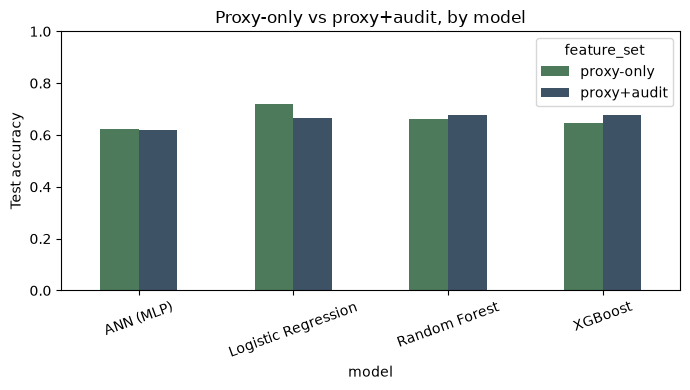

In [6]:
pivot = results.pivot(index="model", columns="feature_set", values="test_accuracy")
pivot["accuracy_gap"] = pivot["proxy+audit"] - pivot["proxy-only"]
pivot = pivot[["proxy-only","proxy+audit","accuracy_gap"]].round(3)
print(pivot)

fig, ax = plt.subplots(figsize=(7,4))
pivot[["proxy-only","proxy+audit"]].plot(kind="bar", ax=ax, color=["#4c7a5a","#3e5266"])
ax.set_ylabel("Test accuracy"); ax.set_title("Proxy-only vs proxy+audit, by model")
ax.set_ylim(0,1); plt.xticks(rotation=20); plt.tight_layout(); plt.show()


**Reading this run's numbers** (a single 42-seeded split — Section 8 covers making this
robust to seed choice): the proxy-only **Logistic Regression** is the single best model in
the whole table at 72.0% test accuracy, ahead of every proxy+audit model including its own
proxy+audit version. Random Forest and XGBoost do pick up a real gain from the audit fields
(+1.6 and +3.2 points), but neither catches proxy-only Logistic Regression. The **ANN loses
to every classical model in both feature sets** and is the only model that gets *worse* with
more features — at n=741 there isn't enough data for a 32-16 hidden-unit MLP to earn its
extra capacity over a linear boundary. That's the "does depth help at this scale" question
answered directly: no, not here — a legitimate, reportable finding, not a failed attempt at
one.


## 6. Explainability — what the cheap features are actually picking up

SHAP on the best-performing proxy-only tree model: which of the phone-call-friendly fields drive the prediction most.

Background dataset has 186 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=186 when initializing the masker.


Best proxy-only model: Logistic Regression


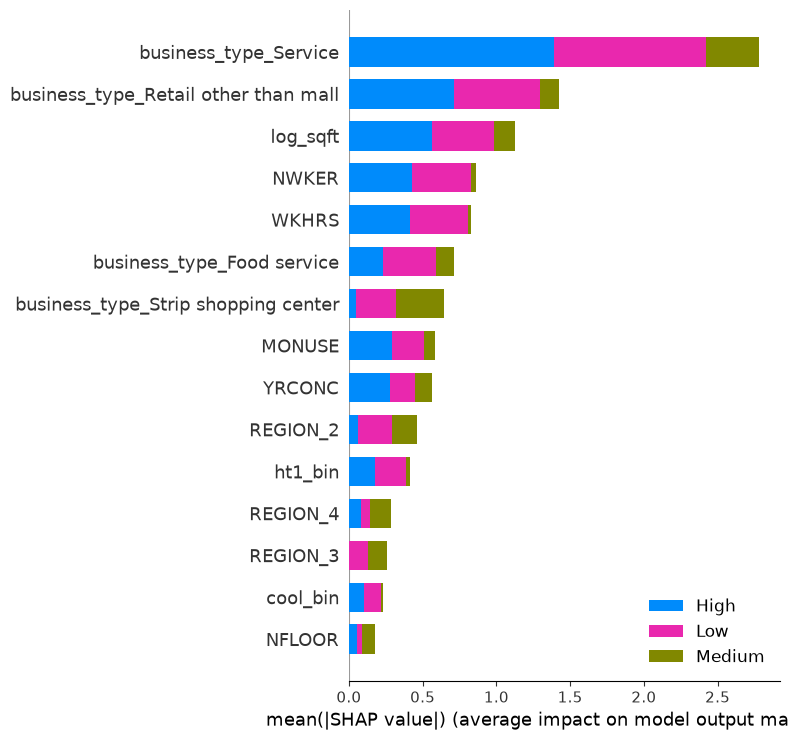

In [7]:
best_proxy_model_name = results_proxy.sort_values("test_accuracy", ascending=False).iloc[0]["model"]
print("Best proxy-only model:", best_proxy_model_name)

model, scaler, Xte, yte, pred = fitted_proxy[best_proxy_model_name]
X_for_shap = Xte if scaler is None else pd.DataFrame(scaler.transform(Xte), columns=Xte.columns, index=Xte.index)

if best_proxy_model_name in ("Random Forest", "XGBoost"):
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_for_shap)
elif best_proxy_model_name == "Logistic Regression":
    explainer = shap.LinearExplainer(model, X_for_shap)
    sv = explainer.shap_values(X_for_shap)
else:
    explainer = shap.KernelExplainer(model.predict_proba, shap.sample(X_for_shap, 50))
    sv = explainer.shap_values(X_for_shap, nsamples=100)

shap.summary_plot(sv, X_for_shap, plot_type="bar", class_names=LABELS, show=False)
plt.tight_layout(); plt.show()


In [8]:
print(classification_report(fitted_proxy[best_proxy_model_name][3],
                             fitted_proxy[best_proxy_model_name][4], target_names=LABELS))
print("Confusion matrix (rows=true, cols=pred), order", LABELS)
print(confusion_matrix(fitted_proxy[best_proxy_model_name][3],
                        fitted_proxy[best_proxy_model_name][4], labels=[0, 1, 2]))


              precision    recall  f1-score   support

         Low       0.70      0.85      0.77        62
      Medium       0.62      0.45      0.52        62
        High       0.82      0.85      0.83        62

    accuracy                           0.72       186
   macro avg       0.71      0.72      0.71       186
weighted avg       0.71      0.72      0.71       186

Confusion matrix (rows=true, cols=pred), order ['Low', 'Medium', 'High']
[[53  9  0]
 [22 28 12]
 [ 1  8 53]]


## 7. Limitations (stated up front, not discovered by a reviewer)

- **Geography:** CBECS is U.S.-only. Results describe U.S. small-commercial buildings; the
  *method* (proxy-vs-audit ablation) transfers, the specific numbers may not.
- **Building, not owner-level:** CBECS surveys the building, not the business — some
  buildings house more than one tenant. Treated as a reasonable proxy for a standalone
  small business at this size/activity filter, not a perfect match.
- **N=741 after filtering**, from an original disclosure-masked survey of 6,436 — a solid
  sample for this course scope, but still worth reporting with cross-validated intervals
  rather than a single point accuracy.
- **The proxy/audit split is a construction**, assigned by us based on what's plausible to
  self-report vs. what needs inspection — not something CBECS itself labels. Documented
  explicitly above (Section 3) so it's checkable, not asserted.
- **Risk tiers are relative to this subset** (tertile cutoffs), not an external certified
  ESG/energy-audit standard.

## 8. Next steps
- Multi-seed error bars (repeat the split 20-50x, report mean ± CI instead of one run).
- A 10-question Streamlit form mapping directly to the proxy feature set, using the trained
  proxy-only model to return a Low/Medium/High score plus the SHAP-ranked drivers.
- Short paper: *"What does it cost to skip the audit? A paired ablation on U.S. small
  commercial buildings."*
